Matriz inicial de feromônio:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]

Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Rotas encontradas:
Formiga 1: [0, 2, 1, 3, 4, 5]
Formiga 2: [0, 1, 2, 3, 4, 5]
Formiga 3: [0, 2, 1, 3, 4, 5]
Formiga 4: [0, 2, 1, 3, 4, 5]
Formiga 5: [0, 1, 2, 4, 5]

Rota: [0, 2, 1, 3, 4, 5]
Custo: 13.0

========== RESULTADO ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Q: 100
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


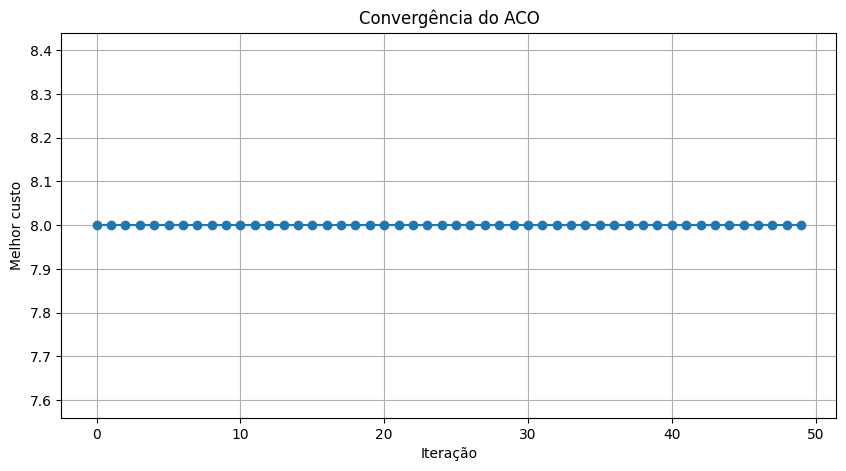


========== MATRIZ FINAL DE FEROMÔNIO ==========
[[8.88178420e-16 5.00000000e+02 2.60509563e-13 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [8.88178420e-16 8.88178420e-16 5.00000000e+02 1.89455289e-13
  0.00000000e+00 0.00000000e+00]
 [8.88178420e-16 8.28738787e-14 8.88178420e-16 5.00000000e+02
  1.54914465e-12 0.00000000e+00]
 [0.00000000e+00 8.88178420e-16 8.88178420e-16 8.88178420e-16
  5.00000000e+02 3.67741752e-14]
 [0.00000000e+00 0.00000000e+00 8.88178420e-16 1.70368770e-14
  8.88178420e-16 5.00000000e+02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.88178420e-16
  8.88178420e-16 8.88178420e-16]]


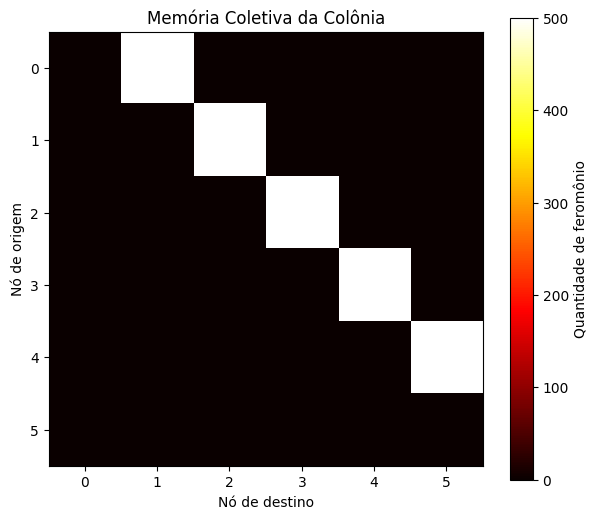

In [5]:
# ============================================================
# LABORATÓRIO — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS
# ============================================================

# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt


# ============================================================
# 2. REPRESENTAÇÃO DA REDE
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================================
# 3. PARÂMETROS DO ACO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100


# ============================================================
# 4. MATRIZ DE FEROMÔNIO
# ============================================================

feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não existe conexão, não existe feromônio.
feromonio[CUSTOS == np.inf] = 0

print("Matriz inicial de feromônio:")
print(feromonio)


# ============================================================
# 5. ENCONTRANDO OS VIZINHOS DE UM NÓ
# ============================================================

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos


# Testes
print("\nVizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))


# ============================================================
# 6. ESCOLHENDO O PRÓXIMO NÓ
# ============================================================

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

    # Remove os nós que a formiga já visitou.
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

        # Quanto maior o feromônio e menor o custo,
        # maior será a atratividade.
        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

    # Transformação das atratividades em probabilidades.
    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

    # Escolha probabilística do próximo nó.
    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


# ============================================================
# 7. CONSTRUINDO UMA ROTA
# ============================================================

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota


# Testando algumas formigas
print("\nRotas encontradas:")

for i in range(5):

    rota = construir_rota()

    print(f"Formiga {i + 1}: {rota}")


# ============================================================
# 8. CALCULANDO O CUSTO DA ROTA
# ============================================================

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total


# Teste de custo
rota = construir_rota()

if rota is not None:

    custo = calcular_custo(rota)

    print("\nRota:", rota)
    print("Custo:", custo)


# ============================================================
# 9. DEPÓSITO DE FEROMÔNIO
# ============================================================

def depositar_feromonio(rota, custo):

    # Quanto menor o custo, maior o depósito.
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


# ============================================================
# 10. EVAPORAÇÃO DO FEROMÔNIO
# ============================================================

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

    # Mantém zero onde não existe conexão.
    feromonio[CUSTOS == np.inf] = 0


# ============================================================
# 11. EXECUTANDO O ACO
# ============================================================

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

    # Cada formiga constrói uma rota.
    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            # Guarda a melhor solução encontrada.
            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

    # Evaporação
    evaporar_feromonio()

    # Depósito de feromônio
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

    # Guarda o melhor custo da iteração.
    historico.append(melhor_custo)


# ============================================================
# 12. RESULTADO
# ============================================================

print("\n========== RESULTADO ==========")

print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Q:", Q)

print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)


# ============================================================
# 13. CURVA DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    historico,
    marker="o"
)

plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO")

plt.grid()

plt.show()


# ============================================================
# 14. MATRIZ FINAL DE FEROMÔNIO
# ============================================================

print("\n========== MATRIZ FINAL DE FEROMÔNIO ==========")
print(feromonio)

plt.figure(figsize=(7, 6))

plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title("Memória Coletiva da Colônia")

plt.show()
